In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
import warnings
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

root        = '../'
data_file   = '03_data/data_for_experiments/'
output_file = '05_output/'
start_date  = '200101'
end_date    = '202412'

os.makedirs(root + output_file, exist_ok=True)

temp_dir = "D:/github_repositories"
os.makedirs(temp_dir, exist_ok=True)

# 强制覆盖环境变量
os.environ["TEMP"] = temp_dir
os.environ["TMP"] = temp_dir
os.environ["JOBLIB_TEMP_FOLDER"] = temp_dir # 专门针对 joblib

In [ ]:
# # creat small data samples
# root        = '../'
# data_file   = '03_data/'

# all_signals = pd.read_parquet(root + data_file + 'WRDS/all_signals.parquet')
# all_signals.rename(columns={'yyyymm': 'date'}, inplace=True)
# all_signals['date'] = all_signals['date'].astype(str)
# all_signals = all_signals[(all_signals['date'] >= start_date) & (all_signals['date'] <= end_date)]
# os.makedirs(root + data_file + 'data_for_experiments/', exist_ok=True)
# all_signals.to_pickle(root + data_file + 'data_for_experiments/all_signals.pickle')
# del all_signals
# print('signals done')

# crsp_d = pd.read_parquet(root + data_file + 'WRDS/crsp_d.parquet')
# crsp_d = crsp_d[(crsp_d['date'] >= start_date[:4] + '-' + start_date[4:] + '-01') & (crsp_d['date'] <= end_date[:4] + '-' + end_date[4:] + '-31')]
# crsp_d.reset_index(drop=True, inplace=True)
# crsp_d.to_pickle(root + data_file + 'data_for_experiments/stock_daily.pickle')
# del crsp_d
# print('stock done')

In [ ]:
# # generate monthly return data from daily return
# stock_daily = pd.read_pickle(root + data_file + 'stock_daily.pickle')
# stock_daily['month'] = stock_daily['date'].apply(lambda x: x[:7])
# stock_daily.sort_values(by=['permno', 'date'], inplace=True)
# stock_monthly = stock_daily.groupby(['permno', 'month']).agg(
#     ret       = ('ret',    'sum'),
#     prc       = ('prc',    'last'),
#     shrout    = ('shrout', 'last'),
#     vol       = ('vol',    'sum'),
#     shrcd     = ('shrcd',  'last'),
#     exchcd    = ('exchcd', 'last'),
# ).reset_index()
# stock_monthly['date'] = stock_monthly['month'].apply(lambda x: x.split('-')[0] + x.split('-')[1])
# stock_monthly = stock_monthly[['permno', 'date', 'ret', 'prc', 'shrout', 'vol', 'shrcd', 'exchcd']]
# os.makedirs(root + output_file + 'stock_monthly/', exist_ok=True)
# stock_monthly.to_pickle(root + output_file + 'stock_monthly/stock_monthly.pickle')

In [ ]:
# import wrds
# db = wrds.Connection(wrds_username = 'dunran')
# sp500list = db.raw_sql("SELECT * FROM crsp.dsp500list")

In [ ]:
signal_doc = pd.read_csv(root + '03_data/SignalDoc.csv')
signal_doc['Filter'] = signal_doc['Filter'].fillna('0')
signal_list = signal_doc[
    (signal_doc['Predictability in OP'] == '1_clear')
    & (signal_doc['Signal Rep Quality'] == '1_good')
    & (signal_doc['Cat.Form'] == 'continuous')
]['Acronym'].tolist()

signals = pd.read_pickle(root + data_file + 'all_signals.pickle')
signals = signals[['permno', 'date'] + signal_list]

nan_pct = signals.isnull().mean()
nan_pct = nan_pct[nan_pct < 0.3]
signals = signals[(list(nan_pct.index))]

In [ ]:
stock_monthly = pd.read_pickle(root + output_file + 'stock_monthly/stock_monthly.pickle')
stock_monthly = stock_monthly[(stock_monthly['prc'] >= 5)]
stock_monthly = stock_monthly.merge(
    right = signals,
    on    = ['permno', 'date'],
    how   = 'left',
).dropna()

In [ ]:
def Equal_Weighted(returns_array, c):
    n_stocks = returns_array.shape[1]
    if c == True:
        weight = np.zeros((n_stocks, 1))
        weight[0, 0] = 1
    else:
        weight = 1.0 / n_stocks
        weight = np.full((n_stocks, 1), weight)
    return weight

def DRMV(returns, delta = 0.1, p = 2):
    n, d = returns.shape
    mu = np.mean(returns, axis=0)
    Sigma = returns.T @ returns / n
    V = Sigma - np.outer(mu, mu)
    V += np.eye(V.shape[0]) * 1e-9
    
    def objective(phi):
        return float(np.sqrt(phi.T @ V @ phi) + np.sqrt(delta) * np.linalg.norm(phi, ord=p))
    
    cons = [
        {'type': 'eq',   'fun': lambda phi: np.sum(phi) - 1.0},
    ]
    
    res = minimize(objective, x0=np.ones(d)/d, method='SLSQP', constraints=cons,
        options={'disp': False, 'maxiter': 500, 'ftol': 1e-9},
        tol=1e-9
    )
    
    weights = res.x.reshape(-1, 1)
    weights = weights / np.sum(weights)
    return weights


def DRMV_socp(returns, delta, p, c):
    n, d = returns.shape
    mu = np.mean(returns, axis=0).reshape(-1, 1)
    Sigma = returns.T @ returns / n
    V = Sigma - mu @ mu.T
    V += np.eye(V.shape[0]) * 1e-9
    L = np.linalg.cholesky(V)

    phi = cp.Variable((d, 1))
    objective = cp.Minimize(cp.norm(L.T @ phi) + cp.sqrt(delta) * cp.norm(phi, p))
    if c == True:
        constraints = [phi[0] == 1]
    else:
        constraints = [cp.sum(phi) == 1]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, verbose=False)
    weights = phi.value
    return weights.reshape(-1, 1)

In [ ]:
# from joblib import Parallel, delayed
# from tqdm.auto import tqdm

# def _single_iter(data, T, N, strategy_num, s):
#     rng = np.random.default_rng(45 + s)
#     data_cut = data[:, rng.permutation(data.shape[1])[:N]]
#     T_steps = data_cut.shape[0] - T - 1
#     ret = np.zeros((strategy_num, T_steps))

#     for i in range(T_steps):
#         train = data_cut[i:i+T, :]
#         test  = data_cut[i+T+1, :]

#         w = []
#         w.append(Equal_Weighted(train).flatten())
#         for j in range(1, strategy_num - 1):
#             w.append(DRMV_socp(train, 10**(-j+1)).flatten())
#         w.append(DRMV_socp(train, 0).flatten())

#         for j, weight in enumerate(w):
#             ret[j, i] = test @ weight
        
#     return ret


# def evaluate_parallel(data, T, N, iter_num, strategy_num, n_jobs=-1):
#     with Parallel(n_jobs=n_jobs, prefer='processes') as parallel:
#         results = parallel(
#             delayed(_single_iter)(data, T, N, strategy_num, s) 
#             for s in tqdm(range(iter_num), desc=f"N={N}")
#         )
    
#     port_ret = np.stack(results, axis=1)
#     return port_ret

In [ ]:
# def fast_pivot_3d(df, index_col, columns_col, value_cols):
#     row_idx = pd.Categorical(df[index_col], ordered=True)
#     col_idx = pd.Categorical(df[columns_col], ordered=True)
    
#     n_rows = len(row_idx.categories)
#     n_cols = len(col_idx.categories)
#     n_feats = len(value_cols)
    
#     out = np.full((n_rows, n_cols, n_feats), np.nan)
#     out[row_idx.codes, col_idx.codes, :] = df[value_cols].values
    
#     return out.transpose([0, 2, 1]), row_idx.categories, col_idx.categories

# data, dates, permnos = fast_pivot_3d(stock_monthly, 'date', 'permno', ['ret']+list(stock_monthly.columns[9:]))
# data = data[24:-7, :, :]
# data = data[:, :, (np.isnan(data).sum(axis=(0, 1))==0)]

In [ ]:
from joblib import Parallel, delayed
from tqdm.auto import tqdm

def _single_iter(data, T, N, strategy_num, c, s):
    rng = np.random.default_rng(45 + s)
    rsl = rng.permutation(data.shape[2])[:N]
    ret_data_cut = data[:, :1, rsl]
    if c == True:
        sig_data_cut = data[:, 1:, rsl]
        if N > 1:
            sig_data_cut = (sig_data_cut - np.mean(sig_data_cut, axis=2, keepdims=True))/np.std(sig_data_cut, axis=2, keepdims=True)
        else:
            sig_data_cut = (sig_data_cut - np.mean(sig_data_cut, axis=2, keepdims=True))
        sig_data_cut = np.concat([(np.ones(ret_data_cut.shape)/sig_data_cut.shape[2]), sig_data_cut], axis=1)
        sig_data_cut = sig_data_cut[:, (np.isnan(sig_data_cut).sum(axis=(0,2)) == 0), :]
        ret_data_cut = ret_data_cut @ sig_data_cut.transpose([0, 2, 1])
    data_cut = np.squeeze(ret_data_cut, axis=1)

    T_steps = data_cut.shape[0] - T - 1
    ret = np.zeros((strategy_num, T_steps))
    for i in range(T_steps):
        train = data_cut[i:i+T, :]
        test  = data_cut[i+T+1, :]

        w = []
        w.append(Equal_Weighted(train, c).flatten())
        for j in range(1, strategy_num - 1):
            w.append(DRMV_socp(train, 10**(-j), 2, c).flatten())
        w.append(DRMV_socp(train, 0, 2, c).flatten())

        for j, weight in enumerate(w):
            ret[j, i] = test @ weight
        
    return ret


def evaluate_parallel(data, T, N, iter_num, strategy_num, c, n_jobs=-1):
    with Parallel(n_jobs=n_jobs, prefer='processes') as parallel:
        results = parallel(
            delayed(_single_iter)(data, T, N, strategy_num, c = c, s = s) 
            for s in tqdm(range(iter_num), desc=f"N={N}")
        )
        
    port_ret = np.stack(results, axis=1)
    return port_ret

In [ ]:
xret = xret[:, -300:]
chars = chars[:, -300:, :]
is_xret_valid  = ~np.any(np.isnan(xret), axis=1)
is_chars_valid = ~np.any(np.isnan(chars), axis=(1, 2))
valid          = is_xret_valid & is_chars_valid
xret = xret[valid, :]
chars = chars[valid, :, :]
data = np.concat([xret.reshape((*xret.shape, 1)), chars], axis=2).transpose(1, 2, 0)

In [ ]:
data.shape

In [ ]:
iter_num = 100
T = 12
strategy_num = 6
start = 1
end = 24
portfolio_size = [n for n in range(start, end + 1)]
port_ret = np.zeros((len(portfolio_size), strategy_num, iter_num, data.shape[0] - T - 1))

for N in portfolio_size:
    port_ret[N-start] = evaluate_parallel(data, T, N, iter_num, strategy_num, c=False, n_jobs=-1)

np.save('../05_output/new_port_ret(T=12, N_max=24, p=2, c=0).npy', port_ret)

In [ ]:
iter_num = 100
T = 12
strategy_num = 6
start = 1
end = 24
portfolio_size = [n for n in range(start, end + 1)]
port_ret = np.zeros((len(portfolio_size), strategy_num, iter_num, data.shape[0] - T - 1))

for N in portfolio_size:
    port_ret[N-start] = evaluate_parallel(data, T, N, iter_num, strategy_num, c=True, n_jobs=-1)

np.save('../05_output/new_port_ret(T=12, N_max=24, p=2, c=1).npy', port_ret)
# sharpe = port_ret.mean(axis=3)*12 / (port_ret.std(axis=3)*np.sqrt(12))
# mean_sharpe = sharpe.mean(axis=2)

In [ ]:
mean_sharpe = []
port_ret = np.load('../05_output/new_port_ret(T=12, N_max=24, p=2, c=0).npy')
sharpe = port_ret.mean(axis=3)*12 / (port_ret.std(axis=3)*np.sqrt(12))
mean_sharpe.append(sharpe.mean(axis=2))
port_ret = np.load('../05_output/new_port_ret(T=12, N_max=24, p=2, c=1).npy')
sharpe = port_ret.mean(axis=3)*12 / (port_ret.std(axis=3)*np.sqrt(12))
mean_sharpe.append(sharpe.mean(axis=2))
# port_ret = np.load('../05_output/port_ret(T=12, N_max=24, p=1, c=0).npy')
# sharpe = port_ret.mean(axis=3)*12 / (port_ret.std(axis=3)*np.sqrt(12))
# mean_sharpe.append(sharpe.mean(axis=2))
# port_ret = np.load('../05_output/port_ret(T=12, N_max=24, p=1, c=1).npy')
# sharpe = port_ret.mean(axis=3)*12 / (port_ret.std(axis=3)*np.sqrt(12))
# mean_sharpe.append(sharpe.mean(axis=2))

In [ ]:
fig, ax = plt.subplots(1, len(mean_sharpe), figsize=(5*len(mean_sharpe), 5))
for j in range(len(mean_sharpe)):
    data = mean_sharpe[j][:, :]
    x = np.arange(1, data.shape[0] + 1) / 12
    for i, col in enumerate(data.T):
        ax[j].plot(x, col, linewidth=1.5, label=f'Col {i}', alpha=0.85, marker='o')

    ax[j].legend(framealpha=0.6, loc='upper left')
    ax[j].spines[['top', 'right']].set_visible(False)
    ax[j].grid(axis='y', linestyle='--', alpha=0.4)


In [ ]:
# # turn .mat files to .npy files
# import hdf5storage
# all_data = hdf5storage.loadmat('../03_data/ipca_data/all_data.mat')
# all_data['xret']
# charnames   = np.array([str(x[0][0]) for x in all_data['charnames'][0]], dtype=str)
# date        = all_data['date'][:, 0]
# xret        = all_data['xret']
# chars       = all_data['chars']
# np.save('../03_data/ipca_data/charnames.npy', charnames)
# np.save('../03_data/ipca_data/date.npy', date)
# np.save('../03_data/ipca_data/xret.npy', xret)
# np.save('../03_data/ipca_data/chars.npy', chars)

In [2]:
charnames   = np.load('../03_data/ipca_data/charnames.npy')
date        = np.load('../03_data/ipca_data/date.npy')
xret        = np.load('../03_data/ipca_data/xret.npy')
chars       = np.load('../03_data/ipca_data/chars.npy')

In [3]:
def equal_weight(xret, chars):
    N, T        = xret.shape
    valid       = ~np.isnan(xret) & ~np.any(np.isnan(chars), axis=2)
    Nt          = np.sum(valid, axis=0, keepdims=True)
    Nt_mat      = np.tile(Nt, (N, 1))
    weight      = np.where(valid, 1/Nt_mat, np.nan)
    return weight

def value_weight(xret, size):
    me      = size[:, :] 
    valid   = ~np.isnan(xret) & ~np.isnan(me)
    me      = np.where(valid, me, 0)
    totme   = np.sum(me, axis=0, keepdims=True)
    weight  = np.where(valid, me/totme, np.nan)
    return weight

def ppp_port(xret, chars, delta, gamma, p):
    def utilityf(rp, gamma):
        if gamma == 1:
            return cp.log(1+rp)
        else:
            return cp.power(1+rp, 1-gamma)/(1-gamma)
    
    N, T, L     = chars.shape
    valid       = ~np.isnan(xret) & ~np.any(np.isnan(chars), axis=2)
    Nt          = np.sum(valid, axis=0, keepdims=True)
    Nt_mat      = np.tile(Nt, (N, 1))

    chars       = np.where(valid[:, :, np.newaxis], chars, 0.0)
    xret        = np.where(valid, xret, 0.0)

    theta       = cp.Variable((L, 1))
    w           = cp.multiply(cp.squeeze(chars.transpose((1, 0, 2)) @ theta, axis=2), 1/Nt_mat.T) + valid.T/Nt_mat.T
    rp          = cp.sum(cp.multiply(w, xret.transpose(1, 0)), axis=1)
    u           = utilityf(rp, gamma)

    objective   = cp.Minimize(- cp.mean(u) + delta*cp.norm(theta, p))
    # constraints = [w >= 0]
    prob        = cp.Problem(objective)
    prob.solve(solver=cp.CLARABEL, verbose=False)
    
    return theta.value.reshape(-1, 1)

In [ ]:
from joblib import Parallel, delayed
def _single_step(i, xret, chars, size, train_len, port_num, strategy_num, use_chars, p):
    rng = np.random.default_rng(45 + i)
    train_xret  = xret[:, :i+train_len] # xret_cut[:, :-1]
    train_chars = chars[:, :i+train_len, :] # chars_cut[:, :-1, :]
    train_chars = (train_chars - np.nanmean(train_chars, axis=0, keepdims=True))/np.nanstd(train_chars, axis=0, keepdims=True)

    test_xret   = xret[:, i+train_len:i+train_len+1] # xret_cut[:, -1:]
    test_chars  = chars[:, i+train_len:i+train_len+1, :] # chars_cut[:, -1:, :]
    test_size   = size[:, i+train_len:i+train_len+1] # size_cut[:, -1:]
    valid       = (~np.isnan(test_xret) & ~np.any(np.isnan(test_chars), axis=2))
    if np.sum(valid) > port_num and port_num != -1:
        valid_idx           = np.where(valid.flatten())[0]
        idx                 = rng.permutation(valid_idx)[:port_num]
        new_valid           = np.zeros_like(valid)
        new_valid[idx, :]   = 1
    else:
        new_valid           = valid

    test_xret   = np.where(new_valid, test_xret, np.nan)
    test_chars  = np.where(np.tile(new_valid[:, :, np.newaxis], (1, 1, chars.shape[2])), test_chars, np.nan)
    test_chars  = (test_chars - np.nanmean(test_chars, axis=0, keepdims=True))/np.nanstd(test_chars, axis=0, keepdims=True)

    wlist = []

    # equal weight
    weight_e    = equal_weight(test_xret, test_chars)

    # value weight
    weight_v    = value_weight(test_xret, test_size)

    # ppp weight
    theta       = ppp_port(train_xret, train_chars, delta=0, gamma=5, p=2)
    weight_ppp  = np.squeeze(test_chars @ theta, axis=2)*weight_e + weight_v

    weight_e    = np.where(new_valid, weight_e, 0)
    weight_v    = np.where(new_valid, weight_v, 0)
    weight_ppp  = np.where(new_valid, weight_ppp, 0)

    wlist.append(np.squeeze(weight_e, axis=1))
    wlist.append(np.squeeze(weight_v, axis=1))
    wlist.append(np.squeeze(weight_ppp, axis=1))
    
    test_xret   = np.where(new_valid, test_xret, 0)
    port_ret = np.full((strategy_num,), np.nan)
    for j, weight in enumerate(wlist):
        weight  = np.where(~np.isnan(weight), weight, 0)
        port_ret[j] = weight @ test_xret[:, :]
    
    return i, port_ret

def evaluate(xret, chars, train_len, port_num, strategy_num, use_chars=0, p=2, s=0, n_jobs=1):
    N, T, L     = chars.shape
    T_steps     = T-train_len-1
    port_ret    = np.full((strategy_num, T_steps), np.nan)
    size        = chars[:, :, 1]
    with Parallel(n_jobs=n_jobs, prefer='processes') as parallel:
        results = dict(parallel(
            delayed(_single_step)(i, xret, chars, size, train_len, port_num, strategy_num, use_chars, p) for i in tqdm(range(T_steps))
        ))
    for k, v in results.items():
        port_ret[:, k] = v

    return port_ret
charslist = np.where(np.isin(charnames, ['beme', 'lme', 'cum_return_12_2']))[0]
port_ret = evaluate(xret[:, :130], chars[:, :130, charslist], train_len=120, port_num=-1, strategy_num=3, use_chars=0, p=2, s=0, n_jobs=-1)

100%|██████████| 9/9 [00:00<00:00, 38597.89it/s]


[[-0.05413908 -0.08408775 -0.10032326  0.10495638 -0.05963325 -0.08080906
   0.3054698   0.0468155   0.09496613]
 [-0.05634932 -0.08579535 -0.10255317  0.11192323 -0.05681243 -0.07515273
   0.28461478  0.04766879  0.08927349]
 [ 0.08021179 -0.01378268 -0.03005825 -0.02473299 -0.11507117 -0.13736089
   0.38049009  0.05229332  0.06266595]]


In [ ]:
import time
from tqdm.auto import tqdm

def _single_iter_inrand(xret, chars, train_len, port_num, strategy_num, use_chars=0, p=2, s=0):
    
    N, T, L     = chars.shape
    T_steps     = T-train_len-1
    port_ret    = np.full((strategy_num, T_steps), np.nan)
    size        = chars[:, :, 1]
    # chars       = (chars - np.nanmean(chars, axis=0, keepdims=True))/np.nanstd(chars, axis=0, keepdims=True)
    for i in tqdm(range(T_steps)):
        rng = np.random.default_rng(45 + i)
        # xret_cut    = xret[:, :i+train_len+1]
        # chars_cut   = chars[:, :i+train_len+1, :]
        # size_cut    = size[:, :i+train_len+1]

        train_xret  = xret[:, :i+train_len] # xret_cut[:, :-1]
        train_chars = chars[:, :i+train_len, :] # chars_cut[:, :-1, :]
        train_chars = (train_chars - np.nanmean(train_chars, axis=0, keepdims=True))/np.nanstd(train_chars, axis=0, keepdims=True)

        test_xret   = xret[:, i+train_len:i+train_len+1] # xret_cut[:, -1:]
        test_chars  = chars[:, i+train_len:i+train_len+1, :] # chars_cut[:, -1:, :]
        test_size   = size[:, i+train_len:i+train_len+1] # size_cut[:, -1:]
        valid       = (~np.isnan(test_xret) & ~np.any(np.isnan(test_chars), axis=2))
        if np.sum(valid) > port_num and port_num != -1:
            valid_idx           = np.where(valid.flatten())[0]
            idx                 = rng.permutation(valid_idx)[:port_num]
            new_valid           = np.zeros_like(valid)
            new_valid[idx, :]   = 1
        else:
            new_valid           = valid

        test_xret   = np.where(new_valid, test_xret, np.nan)
        test_chars  = np.where(np.tile(new_valid[:, :, np.newaxis], (1, 1, chars.shape[2])), test_chars, np.nan)
        test_chars  = (test_chars - np.nanmean(test_chars, axis=0, keepdims=True))/np.nanstd(test_chars, axis=0, keepdims=True)

        wlist = []

        # equal weight
        weight_e    = equal_weight(test_xret, test_chars)

        # value weight
        weight_v    = value_weight(test_xret, test_size)

        # ppp weight
        theta       = ppp_port(train_xret, train_chars, delta=0, gamma=5, p=2)
        weight_ppp  = np.squeeze(test_chars @ theta, axis=2)*weight_e + weight_v

        weight_e    = np.where(new_valid, weight_e, 0)
        weight_v    = np.where(new_valid, weight_v, 0)
        weight_ppp  = np.where(new_valid, weight_ppp, 0)

        wlist.append(np.squeeze(weight_e, axis=1))
        wlist.append(np.squeeze(weight_v, axis=1))
        wlist.append(np.squeeze(weight_ppp, axis=1))
        
        test_xret   = np.where(new_valid, test_xret, 0)
        for j, weight in enumerate(wlist):
            weight  = np.where(~np.isnan(weight), weight, 0)
            port_ret[j, i] = weight @ test_xret[:, :]

    return port_ret
charslist = np.where(np.isin(charnames, ['beme', 'lme', 'cum_return_12_2']))[0]
port_ret = _single_iter_inrand(xret[:, :130], chars[:, :130, charslist], train_len=120, port_num=-1, strategy_num=3, use_chars=0, p=2, s=0)

100%|██████████| 9/9 [00:07<00:00,  1.16it/s]

[[-0.05413908 -0.08408775 -0.10032326  0.10495638 -0.05963325 -0.08080906
   0.3054698   0.0468155   0.09496613]
 [-0.05634932 -0.08579535 -0.10255317  0.11192323 -0.05681243 -0.07515273
   0.28461478  0.04766879  0.08927349]
 [ 0.08021179 -0.01378268 -0.03005825 -0.02473299 -0.11507117 -0.13736089
   0.38049009  0.05229332  0.06266595]]


In [ ]:
charslist = np.where(np.isin(charnames, ['beme', 'lme', 'cum_return_12_2']))[0]
port_ret = _single_iter_inrand(xret[:, :300], chars[:, :300, charslist], train_len=120, port_num=-1, strategy_num=3, use_chars=0, p=2, s=0)
results = pd.DataFrame({
    'mean':         np.round(np.mean(port_ret, axis=1)*12, 4), 
    'std':          np.round(np.std(port_ret, axis=1)*np.sqrt(12), 4),
    'sharpe ratio': np.round(np.mean(port_ret, axis=1)*12/(np.std(port_ret, axis=1)*np.sqrt(12)), 4),
}, index=['equal weited', 'value weighted', 'ppp'])
results

,mean,std,sharpe ratio
equal weited,0.1341,0.2230,0.6014
value weighted,0.1278,0.2185,0.5849
ppp,0.3941,0.3192,1.2346


In [84]:
charslist = np.where(np.isin(charnames, ['beme', 'lme', 'cum_return_12_2']))[0]
port_ret = _single_iter_inrand(xret[:, :300], chars[:, :300, charslist], train_len=120, port_num=100, strategy_num=3, use_chars=0, p=2, s=0)
results = pd.DataFrame({
    'mean':         np.round(np.mean(port_ret, axis=1)*12, 4), 
    'std':          np.round(np.std(port_ret, axis=1)*np.sqrt(12), 4),
    'sharpe ratio': np.round(np.mean(port_ret, axis=1)*12/(np.std(port_ret, axis=1)*np.sqrt(12)), 4),
}, index=['equal weited', 'value weighted', 'ppp'])
results

100%|██████████| 179/179 [04:45<00:00,  1.59s/it]


,mean,std,sharpe ratio
equal weited,0.1277,0.2262,0.5644
value weighted,0.1224,0.2208,0.5546
ppp,0.4802,0.5120,0.9378


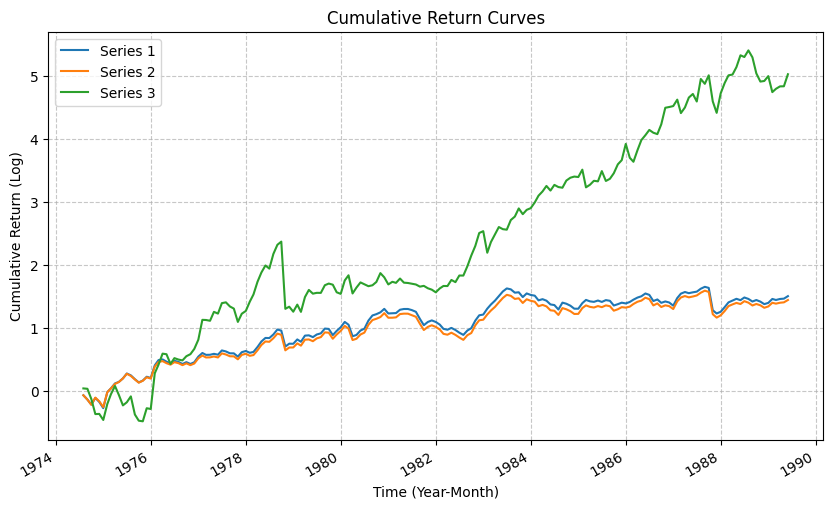

In [92]:
def plot_cumulative_returns(x_axis, *return_series):
    plt.figure(figsize=(10, 6))
    
    # --- 核心修改：将 YYYYMM 格式转换为真实的日期对象 ---
    # errors='coerce' 可以处理可能的异常数据
    # format='%Y%m' 对应 196107 这种格式
    x_date = pd.to_datetime(x_axis, format='%Y%m', errors='coerce')
    
    for i, series in enumerate(return_series, start=1):
        series = np.asarray(series, dtype=float)
        
        # 计算对数累计收益
        cumulative = np.cumsum(np.log(1 + series))
        
        # 绘图时使用转换后的 x_date
        plt.plot(x_date, cumulative, label=f"Series {i}")
    
    # 自动调整日期标签的倾斜度，防止重叠
    plt.gcf().autofmt_xdate()
    
    plt.xlabel("Time (Year-Month)")
    plt.ylabel("Cumulative Return (Log)")
    plt.title("Cumulative Return Curves")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
plot_cumulative_returns(date[121:300], port_ret[0], port_ret[1], port_ret[2])

In [ ]:
def plot_cumulative_returns(*return_series):

    plt.figure(figsize=(10, 6))
    
    for i, series in enumerate(return_series, start=1):
        series = np.asarray(series, dtype=float)
        cumulative = np.cumprod(1 + series)
        # cumulative = np.cumsum(series)
        plt.plot(cumulative, label=str(i))
    
    plt.xlabel("Time")
    plt.ylabel("Cumulative Return")
    plt.title("Cumulative Return Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_cumulative_returns(port_ret[0])